# 02 — Exploratory Data Analysis & KPI Definitions

This notebook builds a business-level picture of the Olist platform using the
cleaned order-level data produced in notebook 01. We define and compute the five
core KPIs that frame every downstream analysis: revenue trends, retention,
category mix, delivery quality, and a single-table executive summary.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..').resolve()))

from src.data_processing import load_processed

PROC_PATH = Path('../data/processed/orders_master.parquet')
FIG_DIR   = Path('../outputs/figures')
TBL_DIR   = Path('../outputs/tables')

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_columns', 40)

df = load_processed(PROC_PATH)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Date range: {df["order_purchase_timestamp"].min().date()}  →  {df["order_purchase_timestamp"].max().date()}')
df.head(3)

Loaded: 96,477 rows x 18 cols
Date range: 2016-10-03  →  2018-08-29


,order_id,customer_unique_id,customer_state,seller_state,order_purchase_timestamp,order_month,cohort_month,cohort_index,order_year,order_dow,order_hour,delivery_days,revenue,payment_installments,item_count,avg_item_price,review_score,product_category
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,RJ,SP,2017-09-13 08:59:02,2017-09,2017-09,0,2017,2,8,7.0000,72.1900,2.0000,1.0000,58.9000,5.0000,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,SP,SP,2017-04-26 10:53:06,2017-04,2017-04,0,2017,2,10,16.0000,259.8300,3.0000,1.0000,239.9000,4.0000,pet_shop
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,MG,MG,2018-01-14 14:33:31,2018-01,2018-01,0,2018,6,14,7.0000,216.8700,5.0000,1.0000,199.0000,5.0000,furniture_decor


## 1. Monthly Revenue and Order Volume Trends

We aggregate orders by calendar month to see whether the business is growing,
and whether revenue and order count are moving together. If orders grow faster
than revenue, average order value is declining — a signal of pricing pressure
or a shift toward lower-ticket categories. We also track monthly unique customers
to separate volume growth from customer-base growth.

In [2]:
monthly = (
    df.groupby('order_month')
    .agg(
        total_revenue      = ('revenue', 'sum'),
        order_count        = ('order_id', 'count'),
        unique_customers   = ('customer_unique_id', 'nunique'),
        avg_order_value    = ('revenue', 'mean'),
        median_order_value = ('revenue', 'median'),
    )
    .sort_index()
    .reset_index()
)

monthly.to_csv(TBL_DIR / '02_monthly_kpis.csv', index=False)
print(f'Saved → {TBL_DIR / "02_monthly_kpis.csv"}')
monthly.tail(6)

Saved → ../outputs/tables/02_monthly_kpis.csv


,order_month,total_revenue,order_count,unique_customers,avg_order_value,median_order_value
16,2018-03,"1,120,678.0000",7003,6914,160.0283,106.7300
17,2018-04,"1,132,933.9500",6798,6744,166.6570,109.1650
18,2018-05,"1,128,836.6900",6749,6693,167.2598,108.5500
19,2018-06,"1,012,090.6800",6099,6061,165.9437,112.0900
20,2018-07,"1,027,903.8600",6159,6100,166.8946,108.9600
21,2018-08,"985,414.2800",6351,6310,155.1589,100.6700


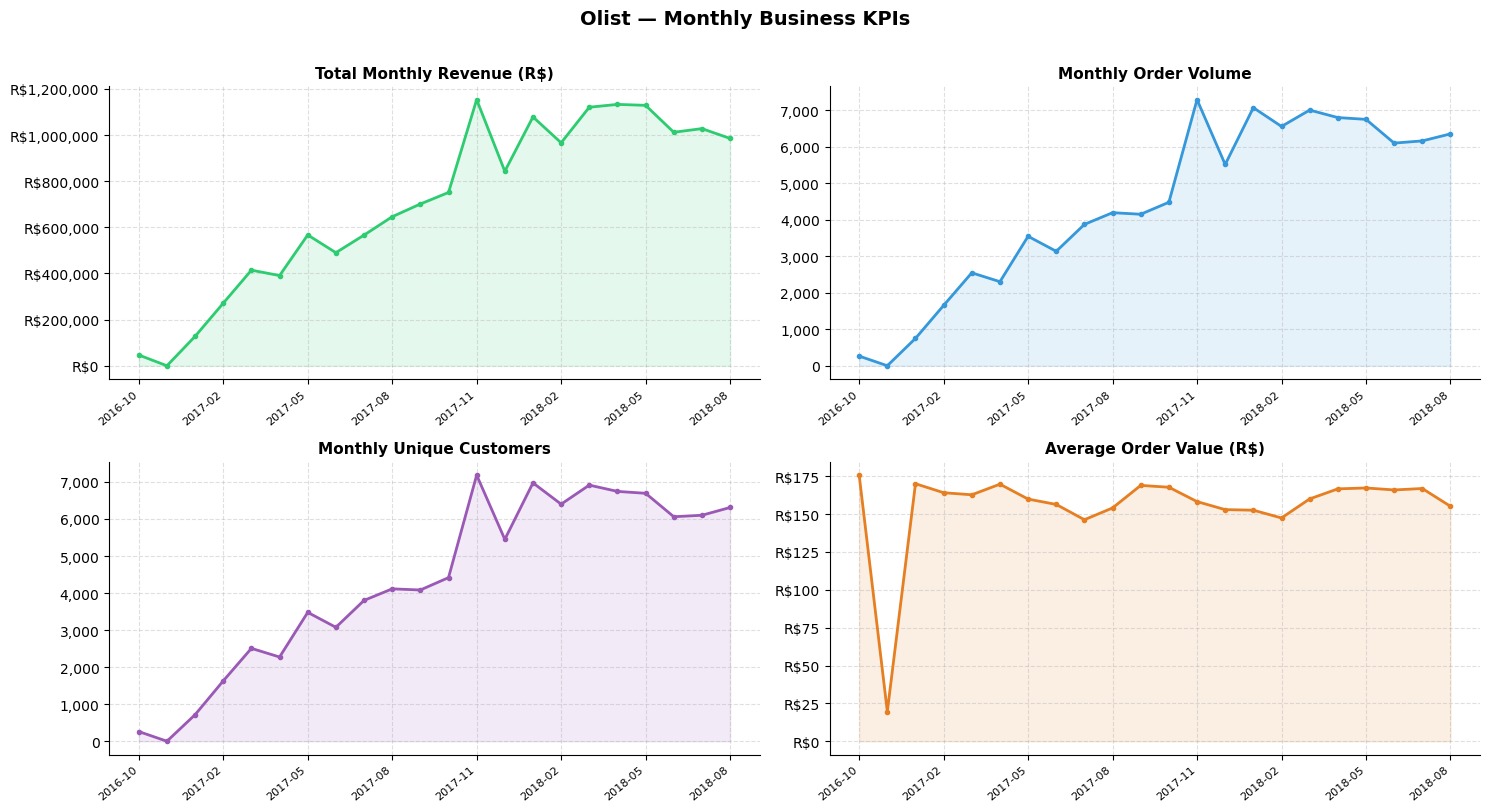

In [3]:
x      = range(len(monthly))
labels = monthly['order_month'].astype(str).tolist()
tick_x = x[::3]
tick_l = labels[::3]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

specs = [
    ('total_revenue',      'Total Monthly Revenue (R$)', '#2ecc71',  True),
    ('order_count',        'Monthly Order Volume',       '#3498db',  False),
    ('unique_customers',   'Monthly Unique Customers',   '#9b59b6',  False),
    ('avg_order_value',    'Average Order Value (R$)',   '#e67e22',  True),
]

for ax, (col, title, color, is_currency) in zip(axes.flatten(), specs):
    ax.plot(x, monthly[col], color=color, linewidth=2, marker='o', markersize=3, zorder=3)
    ax.fill_between(x, monthly[col], alpha=0.12, color=color)
    ax.set_xticks(tick_x)
    ax.set_xticklabels(tick_l, rotation=40, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    fmt = mticker.FuncFormatter(lambda v, _: f'R${v:,.0f}') if is_currency else mticker.FuncFormatter(lambda v, _: f'{v:,.0f}')
    ax.yaxis.set_major_formatter(fmt)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Olist — Monthly Business KPIs', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_monthly_kpis.png', dpi=150, bbox_inches='tight')
plt.show()

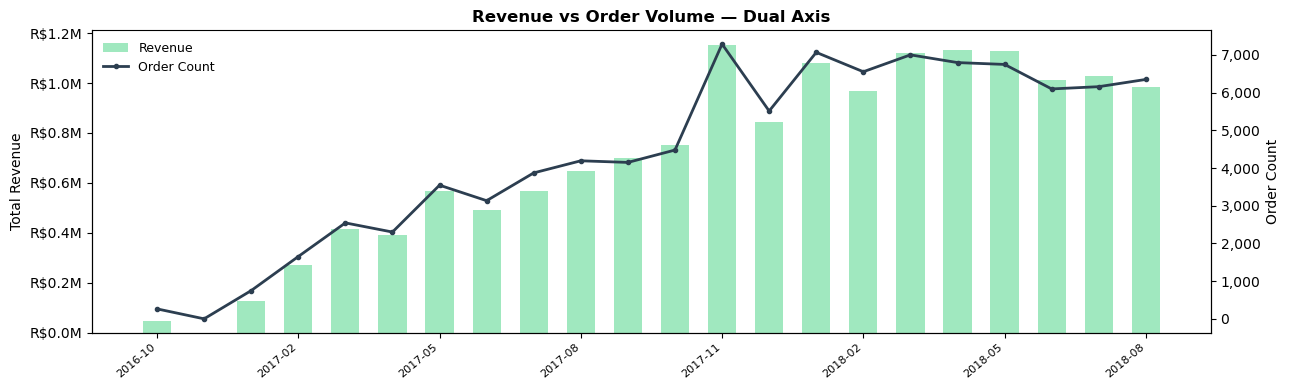

In [4]:
# Revenue and order volume on a dual axis to surface any divergence
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

ax1.bar(x, monthly['total_revenue'], color='#2ecc71', alpha=0.45, width=0.6, label='Revenue')
ax2.plot(x, monthly['order_count'], color='#2c3e50', linewidth=2,
         marker='o', markersize=3, label='Order Count')

ax1.set_xticks(tick_x)
ax1.set_xticklabels(tick_l, rotation=40, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v/1e6:.1f}M'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax1.set_ylabel('Total Revenue', fontsize=10)
ax2.set_ylabel('Order Count', fontsize=10)
ax1.set_title('Revenue vs Order Volume — Dual Axis', fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=9)
ax1.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_revenue_vs_volume_dual.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Repeat Purchase Rate

Repeat purchase rate is the single most important retention metric for an
e-commerce business. We measure it as the share of customers who placed more
than one order over the entire dataset window. A low rate is not necessarily
a failure — Olist is a marketplace for one-off goods — but it sets the baseline
for interpreting CLV and cohort retention in later notebooks.

In [5]:
cust_orders = (
    df.groupby('customer_unique_id')['order_id']
    .count()
    .reset_index(name='order_count')
)

repeat_rate     = (cust_orders['order_count'] > 1).mean() * 100
single_buyers   = (cust_orders['order_count'] == 1).sum()
repeat_buyers   = (cust_orders['order_count'] > 1).sum()
max_orders      = cust_orders['order_count'].max()

print(f'Repeat purchase rate  : {repeat_rate:.2f}%')
print(f'Single-purchase buyers: {single_buyers:,}  ({single_buyers/len(cust_orders)*100:.1f}%)')
print(f'Repeat buyers         : {repeat_buyers:,}  ({repeat_buyers/len(cust_orders)*100:.1f}%)')
print(f'Max orders / customer : {max_orders}')

Repeat purchase rate  : 3.00%
Single-purchase buyers: 90,556  (97.0%)
Repeat buyers         : 2,801  (3.0%)
Max orders / customer : 15


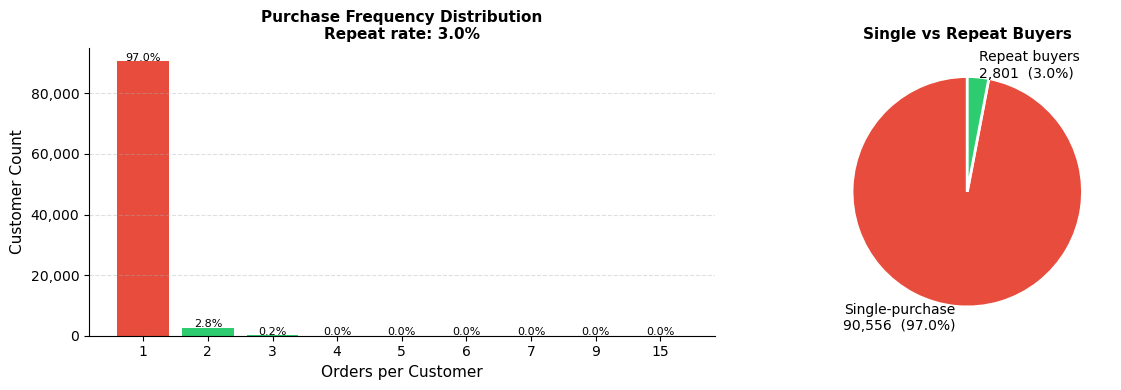

Saved → ../outputs/tables/02_order_frequency_dist.csv


In [6]:
order_dist = cust_orders['order_count'].value_counts().sort_index().head(10)
colors     = ['#e74c3c' if i == 1 else '#2ecc71' for i in order_dist.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

bars = ax1.bar(order_dist.index.astype(str), order_dist.values,
               color=colors, edgecolor='none')
for bar, val in zip(bars, order_dist.values):
    pct = val / len(cust_orders) * 100
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f'{pct:.1f}%', ha='center', fontsize=8)
ax1.set_xlabel('Orders per Customer', fontsize=11)
ax1.set_ylabel('Customer Count', fontsize=11)
ax1.set_title(f'Purchase Frequency Distribution\nRepeat rate: {repeat_rate:.1f}%',
              fontsize=11, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax1.grid(True, axis='y', linestyle='--', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

wedge_sizes  = [single_buyers, repeat_buyers]
wedge_labels = [f'Single-purchase\n{single_buyers:,}  ({100-repeat_rate:.1f}%)',
                f'Repeat buyers\n{repeat_buyers:,}  ({repeat_rate:.1f}%)']
ax2.pie(wedge_sizes, labels=wedge_labels, colors=['#e74c3c', '#2ecc71'],
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Single vs Repeat Buyers', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '02_repeat_purchase_rate.png', dpi=150, bbox_inches='tight')
plt.show()

cust_orders['order_count'].value_counts().sort_index().reset_index().rename(
    columns={'index': 'orders_per_customer', 'order_count': 'customer_count'}
).to_csv(TBL_DIR / '02_order_frequency_dist.csv', index=False)
print(f'Saved → {TBL_DIR / "02_order_frequency_dist.csv"}')

## 3. Category Performance

We look at which product categories generate the most revenue and the most orders,
and whether high-revenue categories also have high average order values or just high
volumes. A scatter of revenue vs average order value reveals which categories are
premium-priced vs volume-driven — useful for deciding where to run promotions
and where to protect margin.

In [7]:
cat_perf = (
    df.dropna(subset=['product_category'])
    .groupby('product_category')
    .agg(
        total_revenue    = ('revenue', 'sum'),
        order_count      = ('order_id', 'count'),
        avg_order_value  = ('revenue', 'mean'),
        avg_review_score = ('review_score', 'mean'),
        unique_customers = ('customer_unique_id', 'nunique'),
    )
    .reset_index()
)
cat_perf['revenue_share_pct'] = (cat_perf['total_revenue'] / cat_perf['total_revenue'].sum() * 100).round(2)
cat_perf = cat_perf.sort_values('total_revenue', ascending=False).reset_index(drop=True)

cat_perf.to_csv(TBL_DIR / '02_category_performance.csv', index=False)
print(f'Saved → {TBL_DIR / "02_category_performance.csv"}')
cat_perf.head(10)

Saved → ../outputs/tables/02_category_performance.csv


,product_category,total_revenue,order_count,avg_order_value,avg_review_score,unique_customers,revenue_share_pct
0,health_beauty,"1,413,962.8400",8620,164.0328,4.2324,8472,9.2900
1,watches_gifts,"1,257,930.5500",5455,230.6014,4.1295,5382,8.2600
2,bed_bath_table,"1,241,401.1100",9240,134.3508,4.0026,8979,8.1500
3,sports_leisure,"1,115,692.7100",7478,149.1967,4.2380,7292,7.3300
4,computers_accessories,"1,037,148.0100",6520,159.0718,4.0821,6395,6.8100
5,furniture_decor,"884,646.2900",6208,142.5010,4.0727,6084,5.8100
6,housewares,"755,133.8800",5671,133.1571,4.2060,5610,4.9600
7,cool_stuff,"688,757.2400",3516,195.8923,4.2345,3501,4.5200
8,auto,"671,719.3500",3804,176.5824,4.1466,3763,4.4100
9,garden_tools,"566,463.2500",3411,166.0696,4.1920,3383,3.7200


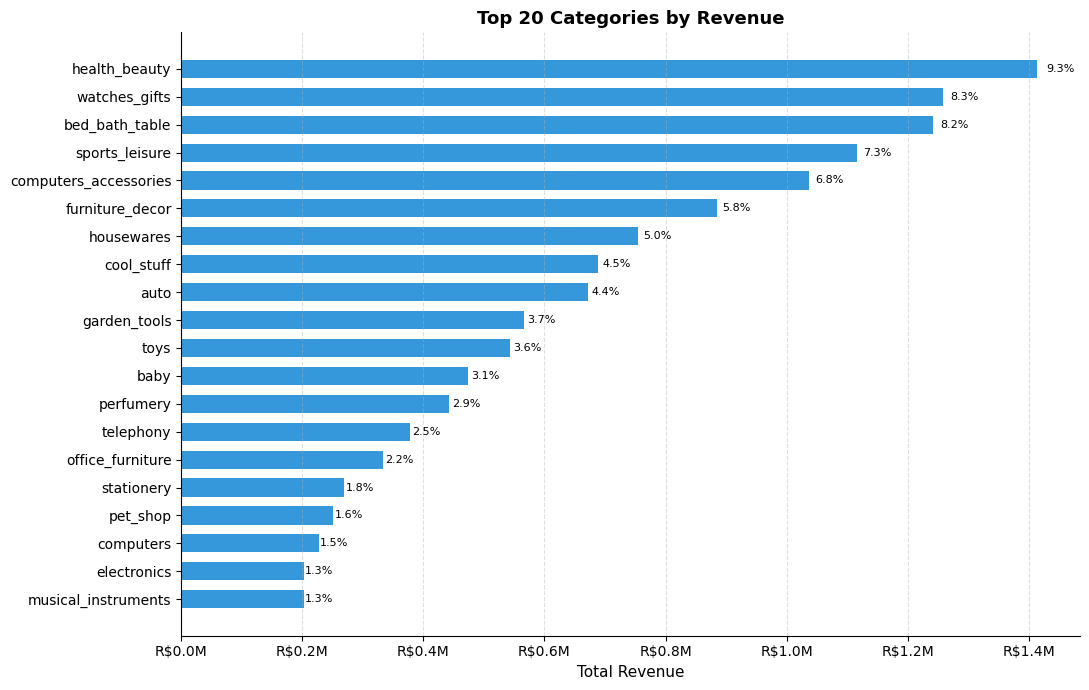

In [8]:
top20 = cat_perf.head(20).sort_values('total_revenue')

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20['product_category'], top20['total_revenue'],
               color='#3498db', edgecolor='none', height=0.65)
for bar, pct in zip(bars, top20['revenue_share_pct']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v/1e6:.1f}M'))
ax.set_xlabel('Total Revenue', fontsize=11)
ax.set_title('Top 20 Categories by Revenue', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_category_revenue_top20.png', dpi=150, bbox_inches='tight')
plt.show()

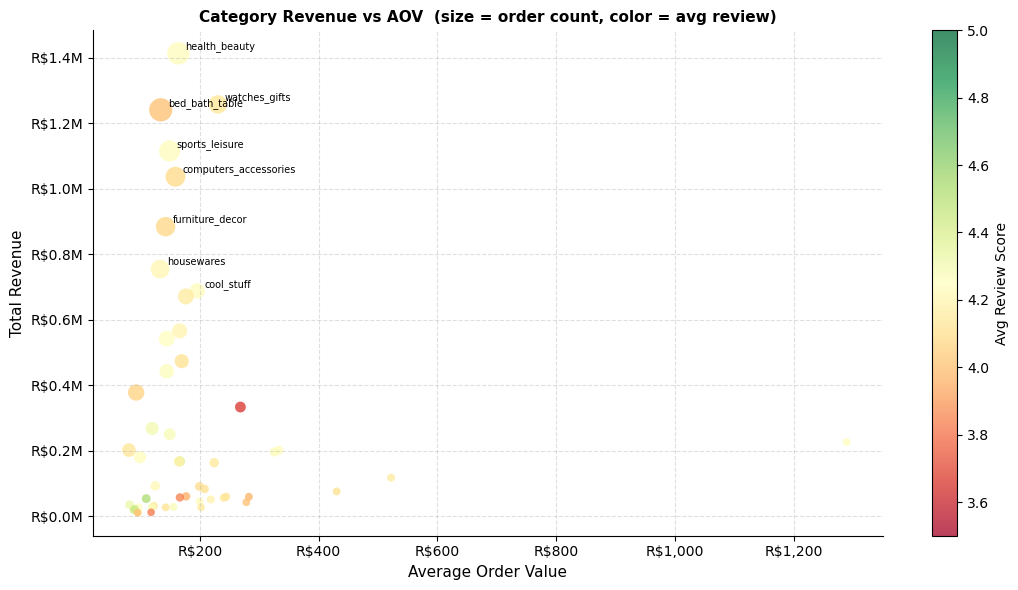

In [9]:
# Revenue vs AOV scatter — reveals premium vs volume-driven categories
plot_cats = cat_perf[cat_perf['order_count'] >= 100].copy()
size_norm = (plot_cats['order_count'] - plot_cats['order_count'].min()) / \
            (plot_cats['order_count'].max() - plot_cats['order_count'].min())

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(
    plot_cats['avg_order_value'],
    plot_cats['total_revenue'],
    s=30 + size_norm * 250,
    c=plot_cats['avg_review_score'],
    cmap='RdYlGn', alpha=0.75, edgecolors='none',
    vmin=3.5, vmax=5.0,
)
plt.colorbar(sc, ax=ax, label='Avg Review Score')

for _, row in plot_cats.nlargest(8, 'total_revenue').iterrows():
    ax.annotate(row['product_category'],
                (row['avg_order_value'], row['total_revenue']),
                fontsize=7, xytext=(5, 3), textcoords='offset points')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v/1e6:.1f}M'))
ax.set_xlabel('Average Order Value', fontsize=11)
ax.set_ylabel('Total Revenue', fontsize=11)
ax.set_title('Category Revenue vs AOV  (size = order count, color = avg review)',
             fontsize=11, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_category_revenue_vs_aov.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Review Score vs Delivery Days Correlation

Customer satisfaction (review score) is a leading indicator of churn. Here we test
whether slower delivery is associated with lower scores. If a strong negative
correlation exists, it means logistics speed is a lever for improving retention —
and justifies using delivery days as a covariate in the A/B analysis in notebook 04.

In [10]:
corr_df = df[['delivery_days', 'review_score']].dropna()
corr_df = corr_df[corr_df['delivery_days'].between(0, 60)]

r, p = stats.pearsonr(corr_df['delivery_days'], corr_df['review_score'])
rho, p_sp = stats.spearmanr(corr_df['delivery_days'], corr_df['review_score'])

print(f'Pearson  r   = {r:.4f}  (p = {p:.2e})')
print(f'Spearman rho = {rho:.4f}  (p = {p_sp:.2e})')

Pearson  r   = -0.3436  (p = 0.00e+00)
Spearman rho = -0.2303  (p = 0.00e+00)


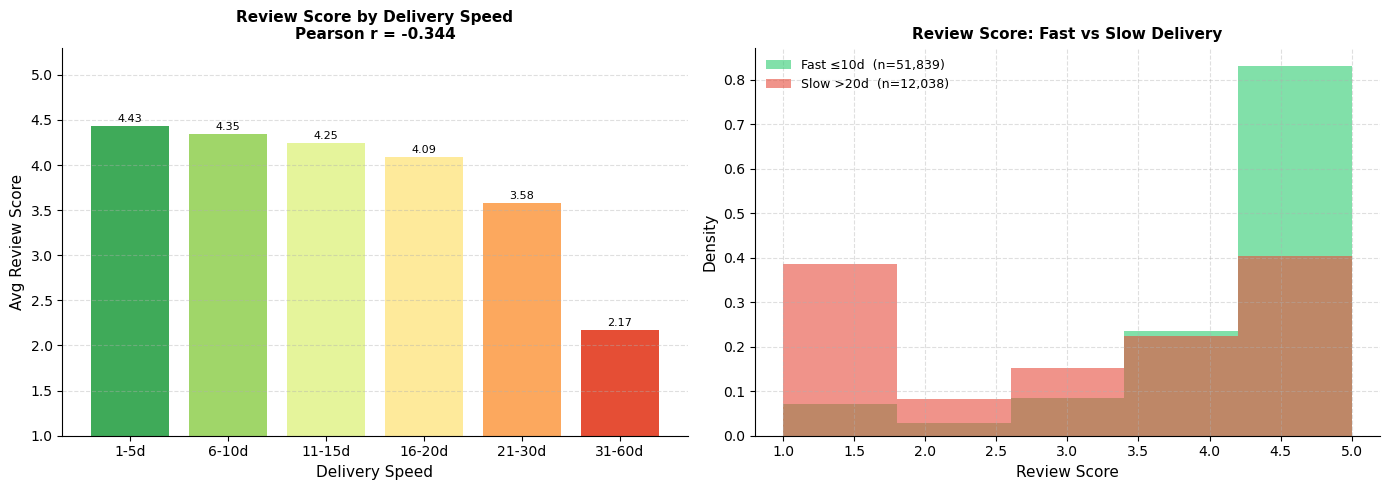

Saved → ../outputs/tables/02_review_by_delivery_bin.csv


In [11]:
corr_df['delivery_bin'] = pd.cut(
    corr_df['delivery_days'],
    bins=[0, 5, 10, 15, 20, 30, 60],
    labels=['1-5d', '6-10d', '11-15d', '16-20d', '21-30d', '31-60d'],
    include_lowest=True,
)
bin_stats = (
    corr_df.groupby('delivery_bin', observed=True)['review_score']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Binned bar — avg review score by delivery speed
bar_colors = plt.cm.RdYlGn(np.linspace(0.85, 0.15, len(bin_stats)))
bars = ax1.bar(bin_stats['delivery_bin'].astype(str), bin_stats['mean'],
               color=bar_colors, edgecolor='none')
for bar, (_, row) in zip(bars, bin_stats.iterrows()):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f'{row["mean"]:.2f}', ha='center', va='bottom', fontsize=8)
ax1.set_ylim(1, 5.3)
ax1.set_xlabel('Delivery Speed', fontsize=11)
ax1.set_ylabel('Avg Review Score', fontsize=11)
ax1.set_title(f'Review Score by Delivery Speed\nPearson r = {r:.3f}',
              fontsize=11, fontweight='bold')
ax1.grid(True, axis='y', linestyle='--', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

# Review score distribution by fast (<= 10d) vs slow (> 20d)
fast = corr_df[corr_df['delivery_days'] <= 10]['review_score']
slow = corr_df[corr_df['delivery_days'] > 20]['review_score']
ax2.hist(fast, bins=5, alpha=0.6, color='#2ecc71', density=True,
         label=f'Fast ≤10d  (n={len(fast):,})')
ax2.hist(slow, bins=5, alpha=0.6, color='#e74c3c', density=True,
         label=f'Slow >20d  (n={len(slow):,})')
ax2.set_xlabel('Review Score', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Review Score: Fast vs Slow Delivery', fontsize=11, fontweight='bold')
ax2.legend(frameon=False, fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_review_vs_delivery.png', dpi=150, bbox_inches='tight')
plt.show()

bin_stats.to_csv(TBL_DIR / '02_review_by_delivery_bin.csv', index=False)
print(f'Saved → {TBL_DIR / "02_review_by_delivery_bin.csv"}')

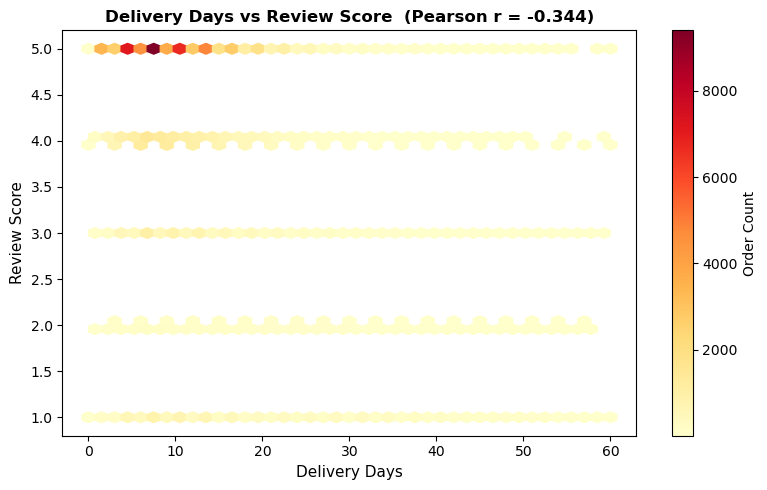

In [12]:
# Hexbin scatter to show density without overplotting
fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(corr_df['delivery_days'], corr_df['review_score'],
               gridsize=40, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=ax, label='Order Count')
ax.set_xlabel('Delivery Days', fontsize=11)
ax.set_ylabel('Review Score', fontsize=11)
ax.set_title(f'Delivery Days vs Review Score  (Pearson r = {r:.3f})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_delivery_review_hexbin.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. KPI Summary Table

We consolidate the headline numbers from all four sections into a single
reference table. This is the executive summary — one row per metric,
formatted for a business audience. It gets saved as a CSV so it can be
pulled into a slide deck or dashboard without re-running the notebook.

In [13]:
top_cat     = cat_perf.iloc[0]
date_range  = (
    f"{df['order_purchase_timestamp'].min().strftime('%b %Y')}"
    f" – {df['order_purchase_timestamp'].max().strftime('%b %Y')}"
)

kpi_summary = pd.DataFrame([
    # Volume
    {'section': 'Volume',      'kpi': 'Total Orders (delivered)',    'value': f"{df['order_id'].count():,}"},
    {'section': 'Volume',      'kpi': 'Unique Customers',            'value': f"{df['customer_unique_id'].nunique():,}"},
    {'section': 'Volume',      'kpi': 'Dataset Date Range',          'value': date_range},
    # Revenue
    {'section': 'Revenue',     'kpi': 'Total Revenue',               'value': f"R${df['revenue'].sum():,.0f}"},
    {'section': 'Revenue',     'kpi': 'Average Order Value',         'value': f"R${df['revenue'].mean():,.2f}"},
    {'section': 'Revenue',     'kpi': 'Median Order Value',          'value': f"R${df['revenue'].median():,.2f}"},
    # Retention
    {'section': 'Retention',   'kpi': 'Repeat Purchase Rate',        'value': f"{repeat_rate:.2f}%"},
    {'section': 'Retention',   'kpi': 'Single-Purchase Customers',   'value': f"{single_buyers:,}  ({100-repeat_rate:.1f}%)"},
    # Delivery
    {'section': 'Delivery',    'kpi': 'Avg Delivery Days',           'value': f"{df['delivery_days'].mean():.1f} days"},
    {'section': 'Delivery',    'kpi': 'Median Delivery Days',        'value': f"{df['delivery_days'].median():.0f} days"},
    # Satisfaction
    {'section': 'Satisfaction','kpi': 'Avg Review Score',            'value': f"{df['review_score'].mean():.3f} / 5"},
    {'section': 'Satisfaction','kpi': 'Delivery–Review Pearson r',   'value': f"{r:.4f}  (p={p:.2e})"},
    # Category
    {'section': 'Category',    'kpi': 'Total Product Categories',    'value': f"{cat_perf['product_category'].nunique()}"},
    {'section': 'Category',    'kpi': '#1 Category by Revenue',      'value': f"{top_cat['product_category']}  (R${top_cat['total_revenue']:,.0f})"},
    {'section': 'Category',    'kpi': '#1 Category Revenue Share',   'value': f"{top_cat['revenue_share_pct']:.1f}%"},
])

kpi_summary.to_csv(TBL_DIR / '02_kpi_summary.csv', index=False)
print(f'Saved → {TBL_DIR / "02_kpi_summary.csv"}')
kpi_summary

Saved → ../outputs/tables/02_kpi_summary.csv


,section,kpi,value
0,Volume,Total Orders (delivered),"96,477"
1,Volume,Unique Customers,"93,357"
2,Volume,Dataset Date Range,Oct 2016 – Aug 2018
3,Revenue,Total Revenue,"R$15,422,462"
4,Revenue,Average Order Value,R$159.86
5,Revenue,Median Order Value,R$105.28
6,Retention,Repeat Purchase Rate,3.00%
7,Retention,Single-Purchase Customers,"90,556 (97.0%)"
8,Delivery,Avg Delivery Days,12.1 days
9,Delivery,Median Delivery Days,10 days


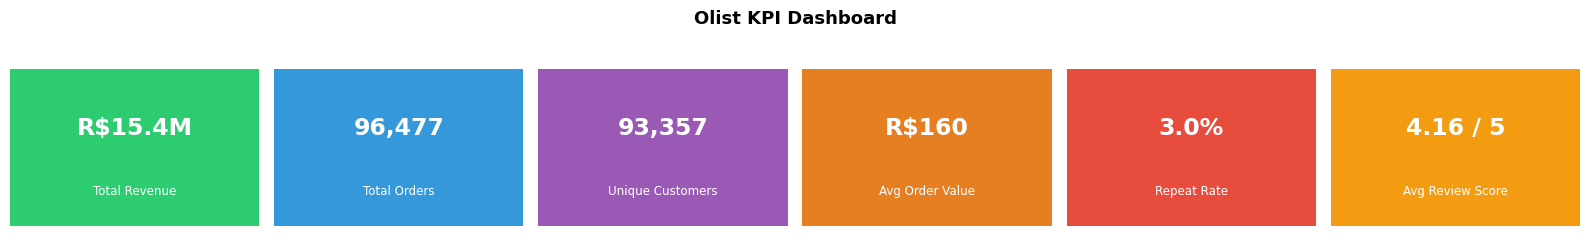

In [14]:
# Visual KPI card summary
headline_kpis = [
    ('Total Revenue',       f"R${df['revenue'].sum()/1e6:.1f}M",    '#2ecc71'),
    ('Total Orders',        f"{df['order_id'].count():,}",           '#3498db'),
    ('Unique Customers',    f"{df['customer_unique_id'].nunique():,}",'#9b59b6'),
    ('Avg Order Value',     f"R${df['revenue'].mean():,.0f}",        '#e67e22'),
    ('Repeat Rate',         f"{repeat_rate:.1f}%",                   '#e74c3c'),
    ('Avg Review Score',    f"{df['review_score'].mean():.2f} / 5",  '#f39c12'),
]

fig, axes = plt.subplots(1, 6, figsize=(16, 2.2))
for ax, (label, value, color) in zip(axes, headline_kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=17, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha='center', va='center',
            fontsize=8.5, color='white', transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle('Olist KPI Dashboard', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_kpi_cards.png', dpi=150, bbox_inches='tight')
plt.show()